In [1]:
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
import utils

In [3]:
ratings = utils.load_ratings()
names = utils.load_items()
print('Ratings:', ratings.shape, '| User:', ratings.user.nunique(), '| Places:', ratings.item.nunique())
ratings.head(5)

Ratings: (1161, 3) | User: 138 | Places: 130


,user,item,rating
0,U1077,135085,2
1,U1077,135038,2
2,U1077,132825,2
3,U1077,135060,1
4,U1068,135104,1


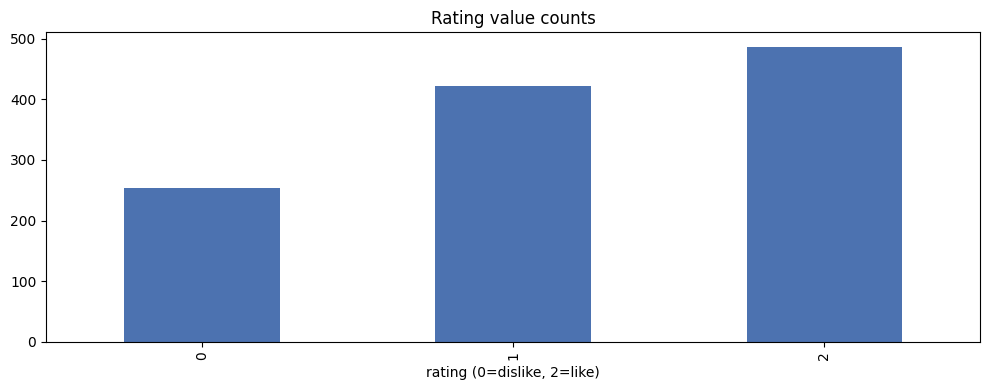

Mean Rating: 1.2


In [7]:
fig, ax = plt.subplots(figsize=(10,4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#4c72b0')
ax.set_title('Rating value counts')
ax.set_xlabel('rating (0=dislike, 2=like)')
plt.tight_layout()
plt.show()
print('Mean Rating:', round(ratings['rating'].mean(),3))

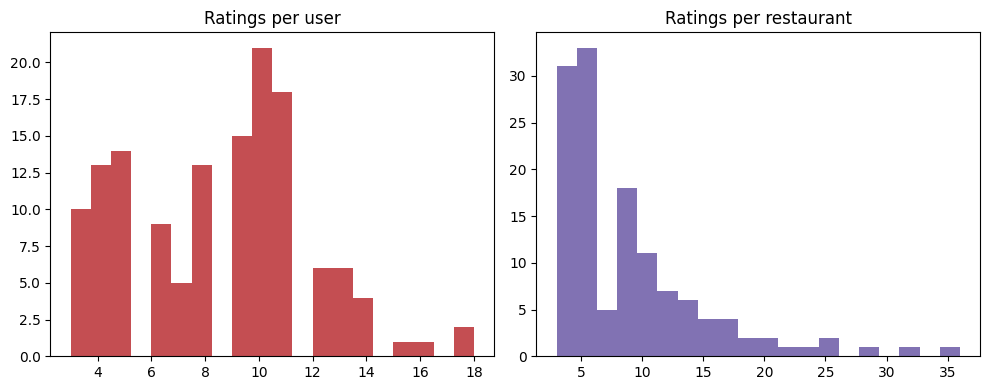

Per user: median 9 max 18
Per item: median 7 max 36


In [8]:
rpu = ratings.groupby('user').size()
rpp = ratings.groupby('item').size()
fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].hist(rpu, bins=20, color='#c44e52')
ax[0].set_title('Ratings per user')
ax[1].set_title('Ratings per restaurant')
ax[1].hist(rpp, bins=20, color='#8172b3')
plt.tight_layout()
plt.show()
print('Per user: median %d max %d' %(rpu.median(), rpu.max()))
print('Per item: median %d max %d' %(rpp.median(), rpp.max()))

In [9]:
n_users, n_items = ratings.user.nunique(), ratings.item.nunique()
density = len(ratings)/(n_users*n_items)
print(f'{n_users} users x {n_items} restaurants = {n_users*n_items:,} cells; {len(ratings):,} ratings')
print('density: %.3f%%  (sparsity %.3f%%)' % (100*density, 100*(1-density)))

138 users x 130 restaurants = 17,940 cells; 1,161 ratings
density: 6.472%  (sparsity 93.528%)


In [10]:
agg = ratings.groupby('item')['rating'].agg(['mean', 'count'])
agg['name'] = agg.index.map(names)

print(agg[agg['count']>=10].sort_values('mean', ascending=False).head(10)[['name', 'count', 'mean']].to_string())

                              name  count      mean
item                                               
135075        Mariscos El Pescador     13  1.692308
135025  El Rincon de San Francisco     15  1.666667
132768          Mariscos Tia Licha     10  1.600000
135030    Preambulo Wifi Zone Cafe     12  1.583333
135028                 La Virreina     15  1.533333
135066          Restaurante Guerra     12  1.500000
135045     Restaurante la Gran Via     13  1.461538
132754             Cabana Huasteca     13  1.461538
135051       Restaurante Versalles     14  1.428571
132723           Gordas de morales     12  1.416667
